<a href="https://colab.research.google.com/github/sungheetha-it/AppsAndTools/blob/main/Synergistic_AI_Models_Personalize_Patient_Healthcare.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## Synergistic AI Models Personalize Patient Healthcare

To personalize patient healthcare using synergistic AI models, we first need a relevant dataset. This dataset should contain patient-specific information that can be used for analysis and model training.

### Dataset Selection Guidance:

1.  **Patient Demographics**: Age, gender, ethnicity, location.
2.  **Clinical Data**: Diagnoses, symptoms, medical history, lab results, medications.
3.  **Treatment History**: Past treatments, their effectiveness, side effects.
4.  **Lifestyle Factors**: Diet, exercise, smoking habits.
5.  **Outcome Data**: Disease progression, treatment response, readmission rates.

You can upload your own `.csv` file or use publicly available datasets like:
*   **MIMIC-III**: A large, freely available database of deidentified patient data.
*   **UCI Machine Learning Repository**: Contains various healthcare-related datasets.
*   **Kaggle**: Many open-source healthcare datasets shared by the community.

Once you have selected or uploaded your dataset, please specify its path in the code cell below.

In [11]:
import pandas as pd

# --- BEGIN: User Input --- #
# Please upload your healthcare CSV file to your Colab environment.
# Once uploaded, right-click the file in the file browser (the folder icon on the left sidebar) and select 'Copy path'.
# Replace 'your_healthcare_dataset.csv' with the actual path to your healthcare dataset.
file_path = 'your_healthcare_dataset.csv' # <--- IMPORTANT: Update this line with your dataset's path
# --- END: User Input --- #

try:
    df = pd.read_csv(file_path)
    print(f"Successfully loaded data from {file_path}.")
    print("Displaying the first 5 rows of the dataset:")
    display(df.head())
    print("\nDataset Information:")
    df.info()
except FileNotFoundError:
    print(f"Error: The file '{file_path}' was not found. Please ensure the file path is correct.")
except Exception as e:
    print(f"An error occurred while loading the dataset: {e}")

Error: The file 'your_healthcare_dataset.csv' was not found. Please ensure the file path is correct.


### Generating Synthetic Healthcare Data

To proceed with the analysis for personalized patient healthcare, let's generate a synthetic dataset. This dataset will include features commonly found in healthcare records, such as patient demographics, diagnoses, treatments, and outcomes, which are essential for building synergistic AI models.

In [13]:
import numpy as np
import pandas as pd

# Set a random seed for reproducibility
np.random.seed(42)

# Number of synthetic patients
num_patients = 1000

# Generate Patient IDs
patient_ids = [f'P{i:04d}' for i in range(num_patients)]

# Generate Age (normally distributed around 55, std dev 15, clipped to 18-90)
age = np.random.normal(loc=55, scale=15, size=num_patients).astype(int)
age = np.clip(age, 18, 90)

# Generate Gender (50% Male, 50% Female)
gender = np.random.choice(['Male', 'Female'], size=num_patients)

# Generate Diagnoses (some common chronic diseases)
diagnoses = np.random.choice(
    ['Hypertension', 'Diabetes Type 2', 'Asthma', 'Osteoarthritis', 'Depression', 'None'],
    p=[0.25, 0.20, 0.15, 0.10, 0.10, 0.20],
    size=num_patients
)

# Generate Treatments (related to diagnoses)
treatments = []
for diag in diagnoses:
    if diag == 'Hypertension':
        treatments.append(np.random.choice(['ACE Inhibitor', 'Beta Blocker', 'Diuretic']))
    elif diag == 'Diabetes Type 2':
        treatments.append(np.random.choice(['Metformin', 'Insulin', 'Lifestyle Changes']))
    elif diag == 'Asthma':
        treatments.append(np.random.choice(['Inhaler', 'Oral Steroids']))
    elif diag == 'Osteoarthritis':
        treatments.append(np.random.choice(['Painkillers', 'Physiotherapy']))
    elif diag == 'Depression':
        treatments.append(np.random.choice(['Antidepressants', 'Therapy']))
    else:
        treatments.append('Observation')

# Generate Treatment Outcome (e.g., 'Improved', 'Stable', 'Worsened')
outcome = []
for t in treatments:
    if t in ['ACE Inhibitor', 'Metformin', 'Inhaler', 'Antidepressants']:
        outcome.append(np.random.choice(['Improved', 'Stable'], p=[0.7, 0.3]))
    elif t == 'Observation':
        outcome.append(np.random.choice(['Stable', 'Worsened'], p=[0.8, 0.2]))
    else:
        outcome.append(np.random.choice(['Improved', 'Stable', 'Worsened'], p=[0.5, 0.4, 0.1]))

# Generate some numerical lab results (e.g., Blood Pressure Sys, Blood Pressure Dia, Glucose, Cholesterol)
bp_sys = np.random.normal(130, 15, num_patients).astype(int)
bp_dia = np.random.normal(80, 10, num_patients).astype(int)
glucose = np.random.normal(100, 20, num_patients).astype(int)
cholesterol = np.random.normal(200, 30, num_patients).astype(int)

# Introduce some correlation with diagnosis/outcome
for i in range(num_patients):
    if 'Hypertension' in diagnoses[i] and outcome[i] == 'Improved':
        bp_sys[i] = int(np.random.normal(120, 5))
        bp_dia[i] = int(np.random.normal(75, 5))
    elif 'Hypertension' in diagnoses[i] and outcome[i] == 'Worsened':
        bp_sys[i] = int(np.random.normal(150, 10))
        bp_dia[i] = int(np.random.normal(95, 10))
    if 'Diabetes' in diagnoses[i] and outcome[i] == 'Improved':
        glucose[i] = int(np.random.normal(90, 10))
    elif 'Diabetes' in diagnoses[i] and outcome[i] == 'Worsened':
        glucose[i] = int(np.random.normal(150, 30))

# Create DataFrame
synthetic_df = pd.DataFrame({
    'patient_id': patient_ids,
    'age': age,
    'gender': gender,
    'diagnosis': diagnoses,
    'treatment': treatments,
    'bp_systolic': bp_sys,
    'bp_diastolic': bp_dia,
    'glucose': glucose,
    'cholesterol': cholesterol,
    'outcome': outcome
})

# Assign the synthetic dataframe to 'df' for further use
df = synthetic_df.copy()

# Display the first 5 rows and information
print("First 5 rows of the synthetic healthcare dataset:")
display(df.head())

print("\nInformation about the synthetic healthcare dataset:")
df.info()

First 5 rows of the synthetic healthcare dataset:


,patient_id,age,gender,diagnosis,treatment,bp_systolic,bp_diastolic,glucose,cholesterol,outcome
0,P0000,62,Male,Depression,Antidepressants,152,67,143,166,Stable
1,P0001,52,Female,Hypertension,Beta Blocker,152,78,122,185,Stable
2,P0002,64,Male,Hypertension,Beta Blocker,96,89,86,158,Stable
3,P0003,77,Female,Hypertension,Beta Blocker,115,65,69,234,Stable
4,P0004,51,Male,None,Observation,95,86,103,140,Stable



Information about the synthetic healthcare dataset:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 10 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   patient_id    1000 non-null   object
 1   age           1000 non-null   int64 
 2   gender        1000 non-null   object
 3   diagnosis     1000 non-null   object
 4   treatment     1000 non-null   object
 5   bp_systolic   1000 non-null   int64 
 6   bp_diastolic  1000 non-null   int64 
 7   glucose       1000 non-null   int64 
 8   cholesterol   1000 non-null   int64 
 9   outcome       1000 non-null   object
dtypes: int64(5), object(5)
memory usage: 78.3+ KB


### Exploratory Data Analysis and Visualization

Now that we have our synthetic healthcare dataset, let's perform some initial exploratory data analysis (EDA) to understand its distributions and relationships. This step is crucial for identifying potential features for our AI models and gaining insights into personalized patient healthcare.


--- Basic Statistics of Numerical Features ---


,age,bp_systolic,bp_diastolic,glucose,cholesterol
count,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000
mean,54.766000,128.804000,78.971000,99.069000,199.918000
std,14.471028,14.426424,9.804708,19.867586,30.424545
min,18.000000,90.000000,49.000000,38.000000,115.000000
25%,45.000000,119.000000,72.000000,85.000000,179.000000
50%,55.000000,127.000000,79.000000,98.000000,200.000000
75%,64.000000,138.000000,85.000000,112.000000,221.000000
max,90.000000,184.000000,110.000000,184.000000,306.000000



--- Distribution of Age ---


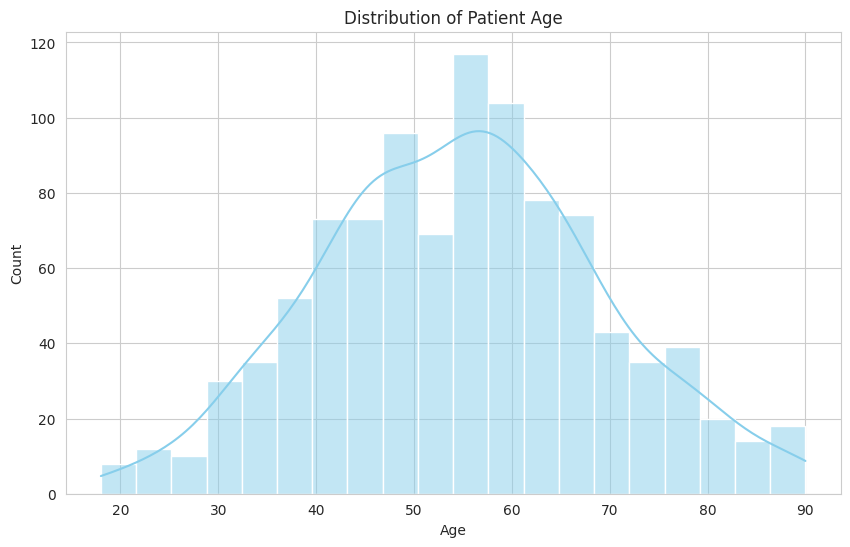


--- Distribution of Gender ---


/tmp/ipykernel_751/3384272060.py:20: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='gender', data=df, palette='viridis')


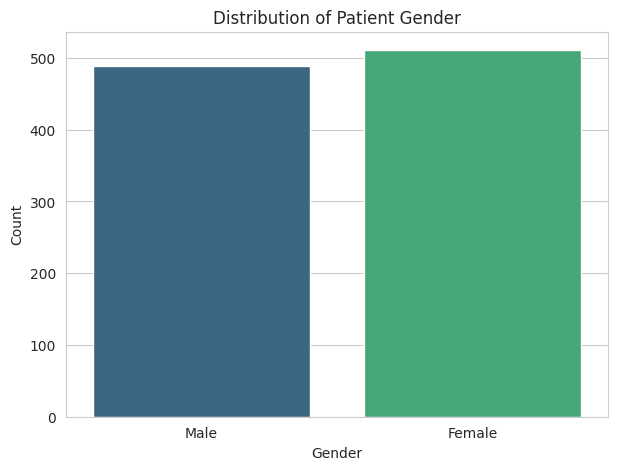


--- Distribution of Diagnoses ---


/tmp/ipykernel_751/3384272060.py:28: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(y='diagnosis', data=df, order=df['diagnosis'].value_counts().index, palette='plasma')


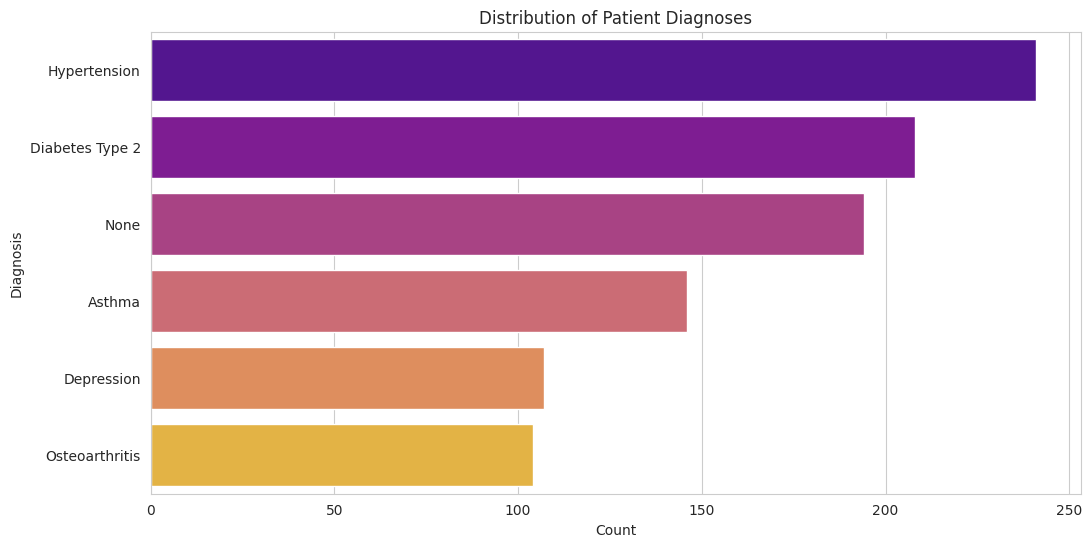


--- Distribution of Treatment Outcomes ---


/tmp/ipykernel_751/3384272060.py:36: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='outcome', data=df, order=df['outcome'].value_counts().index, palette='magma')


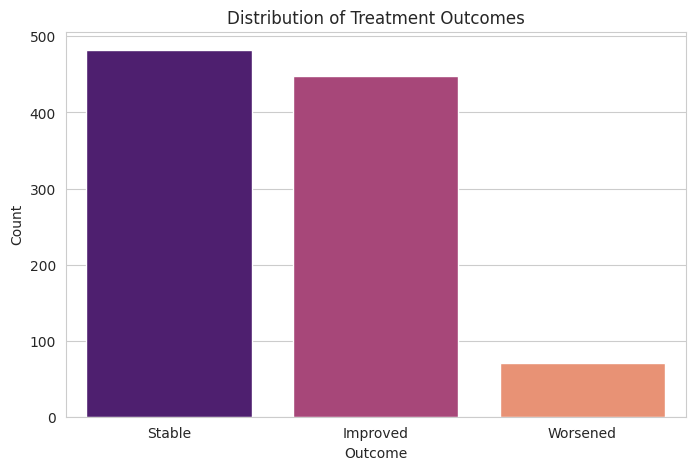

In [14]:
import matplotlib.pyplot as plt
import seaborn as sns

# Set style for plots
sns.set_style("whitegrid")

print("\n--- Basic Statistics of Numerical Features ---")
display(df.describe())

print("\n--- Distribution of Age ---")
plt.figure(figsize=(10, 6))
sns.histplot(df['age'], bins=20, kde=True, color='skyblue')
plt.title('Distribution of Patient Age')
plt.xlabel('Age')
plt.ylabel('Count')
plt.show()

print("\n--- Distribution of Gender ---")
plt.figure(figsize=(7, 5))
sns.countplot(x='gender', data=df, palette='viridis')
plt.title('Distribution of Patient Gender')
plt.xlabel('Gender')
plt.ylabel('Count')
plt.show()

print("\n--- Distribution of Diagnoses ---")
plt.figure(figsize=(12, 6))
sns.countplot(y='diagnosis', data=df, order=df['diagnosis'].value_counts().index, palette='plasma')
plt.title('Distribution of Patient Diagnoses')
plt.xlabel('Count')
plt.ylabel('Diagnosis')
plt.show()

print("\n--- Distribution of Treatment Outcomes ---")
plt.figure(figsize=(8, 5))
sns.countplot(x='outcome', data=df, order=df['outcome'].value_counts().index, palette='magma')
plt.title('Distribution of Treatment Outcomes')
plt.xlabel('Outcome')
plt.ylabel('Count')
plt.show()

### Exploring Relationships for Personalized Healthcare Insights

To understand personalized patient healthcare, it's crucial to examine the interplay between diagnoses, treatments, and patient outcomes. These relationships will guide us in identifying patterns that AI models can leverage for tailored interventions.


--- Relationship: Diagnosis vs. Outcome ---


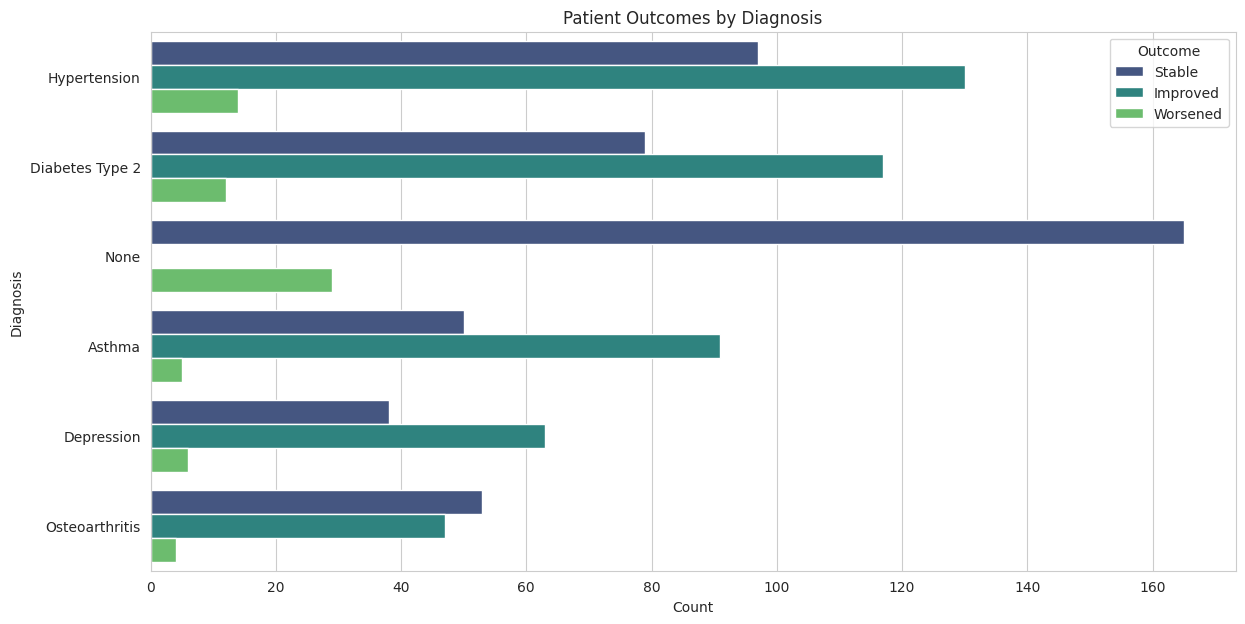


--- Relationship: Treatment vs. Outcome (for Hypertension) ---


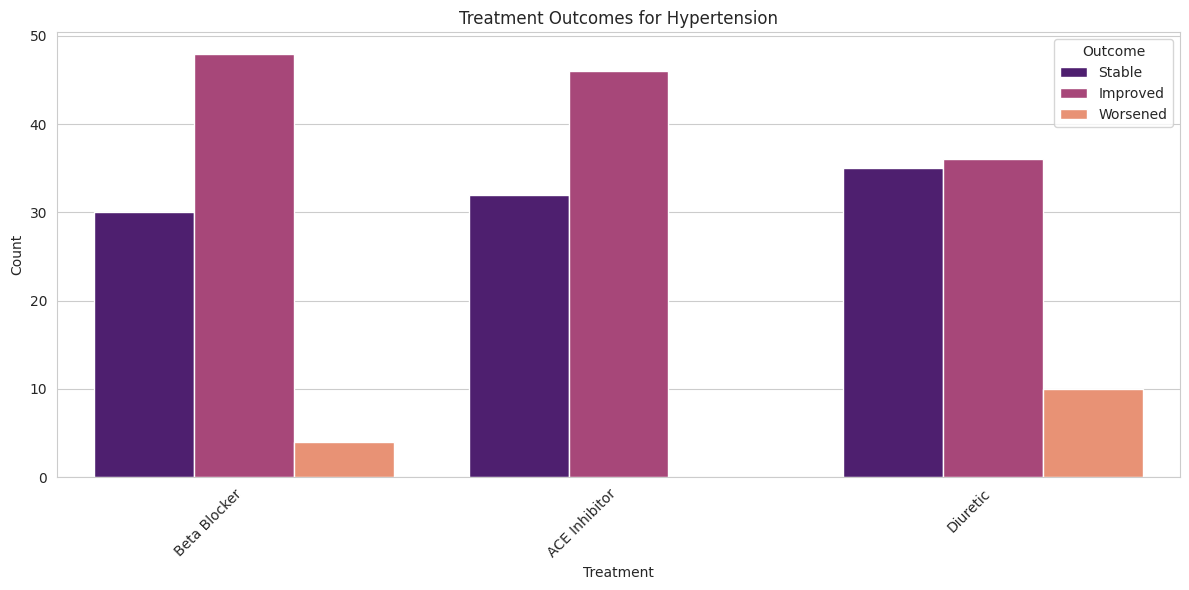


--- Relationship: Treatment vs. Outcome (for Diabetes Type 2) ---


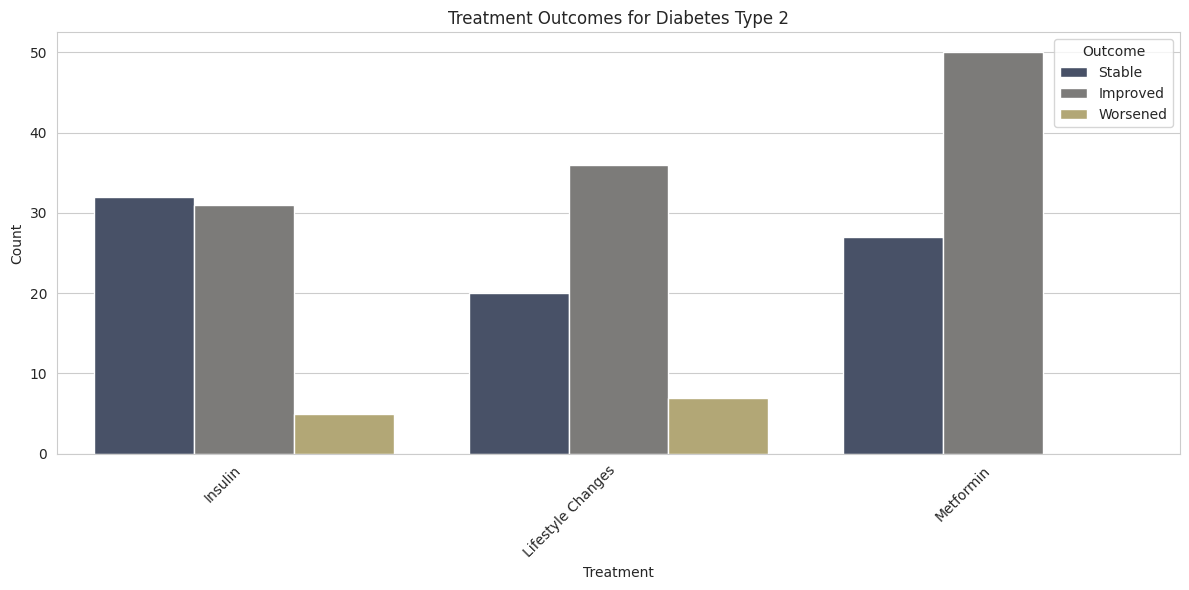


--- Relationship: Age vs. Outcome ---


/tmp/ipykernel_751/3781492242.py:50: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='outcome', y='age', data=df, palette='plasma')


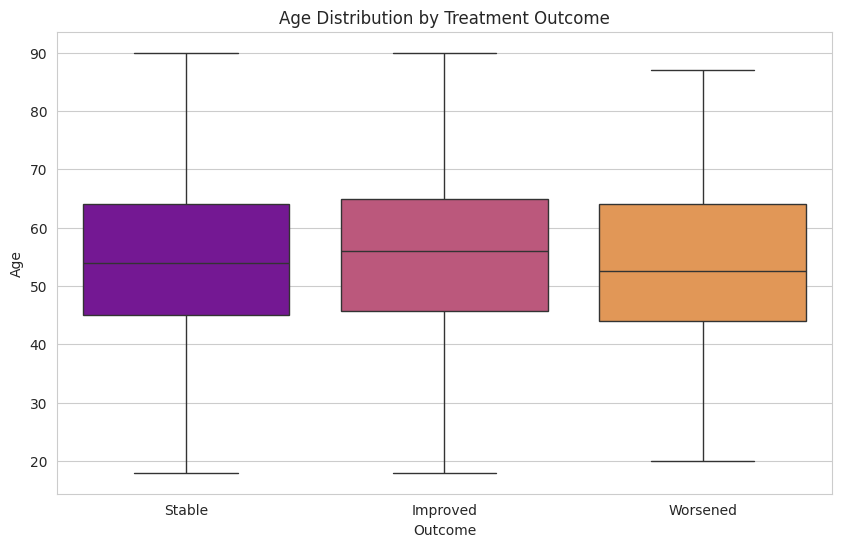

In [15]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")

# --- Relationship between Diagnosis and Outcome ---
print("\n--- Relationship: Diagnosis vs. Outcome ---")
plt.figure(figsize=(14, 7))
sns.countplot(y='diagnosis', hue='outcome', data=df, palette='viridis', order=df['diagnosis'].value_counts().index)
plt.title('Patient Outcomes by Diagnosis')
plt.xlabel('Count')
plt.ylabel('Diagnosis')
plt.legend(title='Outcome')
plt.show()

# --- Relationship between Treatment and Outcome (focused on major diagnoses) ---
print("\n--- Relationship: Treatment vs. Outcome (for Hypertension) ---")
hypertension_df = df[df['diagnosis'] == 'Hypertension']
if not hypertension_df.empty:
    plt.figure(figsize=(12, 6))
    sns.countplot(x='treatment', hue='outcome', data=hypertension_df, palette='magma')
    plt.title('Treatment Outcomes for Hypertension')
    plt.xlabel('Treatment')
    plt.ylabel('Count')
    plt.xticks(rotation=45, ha='right')
    plt.legend(title='Outcome')
    plt.tight_layout()
    plt.show()
else:
    print("No 'Hypertension' cases in the dataset to visualize treatments.")

print("\n--- Relationship: Treatment vs. Outcome (for Diabetes Type 2) ---")
diabetes_df = df[df['diagnosis'] == 'Diabetes Type 2']
if not diabetes_df.empty:
    plt.figure(figsize=(12, 6))
    sns.countplot(x='treatment', hue='outcome', data=diabetes_df, palette='cividis')
    plt.title('Treatment Outcomes for Diabetes Type 2')
    plt.xlabel('Treatment')
    plt.ylabel('Count')
    plt.xticks(rotation=45, ha='right')
    plt.legend(title='Outcome')
    plt.tight_layout()
    plt.show()
else:
    print("No 'Diabetes Type 2' cases in the dataset to visualize treatments.")

# --- Relationship between Age and Outcome ---
print("\n--- Relationship: Age vs. Outcome ---")
plt.figure(figsize=(10, 6))
sns.boxplot(x='outcome', y='age', data=df, palette='plasma')
plt.title('Age Distribution by Treatment Outcome')
plt.xlabel('Outcome')
plt.ylabel('Age')
plt.show()

### Summarizing Treatment Effectiveness for Each Diagnosis

To understand the effectiveness of different treatments, we will analyze the outcomes (`Improved`, `Stable`, `Worsened`) for each treatment within each diagnosis. This summary can help in identifying which treatments tend to lead to better patient outcomes for specific conditions.

In [16]:
print("\n--- Treatment Effectiveness Summary ---")

treatment_effectiveness = df.groupby(['diagnosis', 'treatment', 'outcome']).size().unstack(fill_value=0)
treatment_effectiveness['Total'] = treatment_effectiveness.sum(axis=1)
# Calculate percentages for better comparison
treatment_effectiveness_percent = treatment_effectiveness.div(treatment_effectiveness['Total'], axis=0) * 100

print("Count of Outcomes by Diagnosis and Treatment:")
display(treatment_effectiveness)

print("\nPercentage of Outcomes by Diagnosis and Treatment:")
display(treatment_effectiveness_percent.round(2))


--- Treatment Effectiveness Summary ---
Count of Outcomes by Diagnosis and Treatment:


outcome                            Improved  Stable  Worsened  Total
diagnosis       treatment                                           
Asthma          Inhaler                  63      24         0     87
                Oral Steroids            28      26         5     59
Depression      Antidepressants          38      10         0     48
                Therapy                  25      28         6     59
Diabetes Type 2 Insulin                  31      32         5     68
                Lifestyle Changes        36      20         7     63
                Metformin                50      27         0     77
Hypertension    ACE Inhibitor            46      32         0     78
                Beta Blocker             48      30         4     82
                Diuretic                 36      35        10     81
None            Observation               0     165        29    194
Osteoarthritis  Painkillers              25      30         2     57
                Physiotherapy            22      23         2     47


Percentage of Outcomes by Diagnosis and Treatment:


outcome                            Improved  Stable  Worsened  Total
diagnosis       treatment                                           
Asthma          Inhaler               72.41   27.59      0.00  100.0
                Oral Steroids         47.46   44.07      8.47  100.0
Depression      Antidepressants       79.17   20.83      0.00  100.0
                Therapy               42.37   47.46     10.17  100.0
Diabetes Type 2 Insulin               45.59   47.06      7.35  100.0
                Lifestyle Changes     57.14   31.75     11.11  100.0
                Metformin             64.94   35.06      0.00  100.0
Hypertension    ACE Inhibitor         58.97   41.03      0.00  100.0
                Beta Blocker          58.54   36.59      4.88  100.0
                Diuretic              44.44   43.21     12.35  100.0
None            Observation            0.00   85.05     14.95  100.0
Osteoarthritis  Painkillers           43.86   52.63      3.51  100.0
                Physiotherapy         46.81   48.94      4.26  100.0

### Treatment Recommendation Function

Based on the observed treatment effectiveness, we can create a simple recommendation function. This function will suggest the treatment that has the highest 'Improved' outcome percentage for a given diagnosis.

In [17]:
def recommend_treatment(diagnosis):
    """
    Recommends the best treatment for a given diagnosis based on the highest 'Improved' outcome percentage.
    """
    if diagnosis not in treatment_effectiveness_percent.index.get_level_values('diagnosis'):
        return f"No treatment data available for diagnosis: {diagnosis}"

    # Filter for the specific diagnosis
    diagnosis_data = treatment_effectiveness_percent.loc[diagnosis]

    # Handle cases where 'Improved' column might not exist for some treatments under a diagnosis
    if 'Improved' in diagnosis_data.columns:
        # Find the treatment with the highest 'Improved' percentage
        best_treatment = diagnosis_data['Improved'].idxmax()
        return best_treatment
    else:
        return f"No 'Improved' outcome data for diagnosis: {diagnosis}. Cannot make a recommendation based on improvement."

print("Recommendation function created.")

Recommendation function created.


### Demonstration of the Recommendation Function

Let's test our `recommend_treatment` function with a few diagnoses from our dataset.

In [18]:
print(f"Recommended treatment for Asthma: {recommend_treatment('Asthma')}")
print(f"Recommended treatment for Hypertension: {recommend_treatment('Hypertension')}")
print(f"Recommended treatment for Diabetes Type 2: {recommend_treatment('Diabetes Type 2')}")
print(f"Recommended treatment for Depression: {recommend_treatment('Depression')}")
print(f"Recommended treatment for Osteoarthritis: {recommend_treatment('Osteoarthritis')}")
print(f"Recommended treatment for a non-existent diagnosis: {recommend_treatment('Influenza')}")

Recommended treatment for Asthma: Inhaler
Recommended treatment for Hypertension: ACE Inhibitor
Recommended treatment for Diabetes Type 2: Metformin
Recommended treatment for Depression: Antidepressants
Recommended treatment for Osteoarthritis: Physiotherapy
Recommended treatment for a non-existent diagnosis: No treatment data available for diagnosis: Influenza


### Visualizing Treatment Effectiveness Across All Diagnoses

To get a comprehensive view of treatment effectiveness, let's visualize the percentage of 'Improved', 'Stable', and 'Worsened' outcomes for each treatment within every diagnosis using a stacked bar chart.

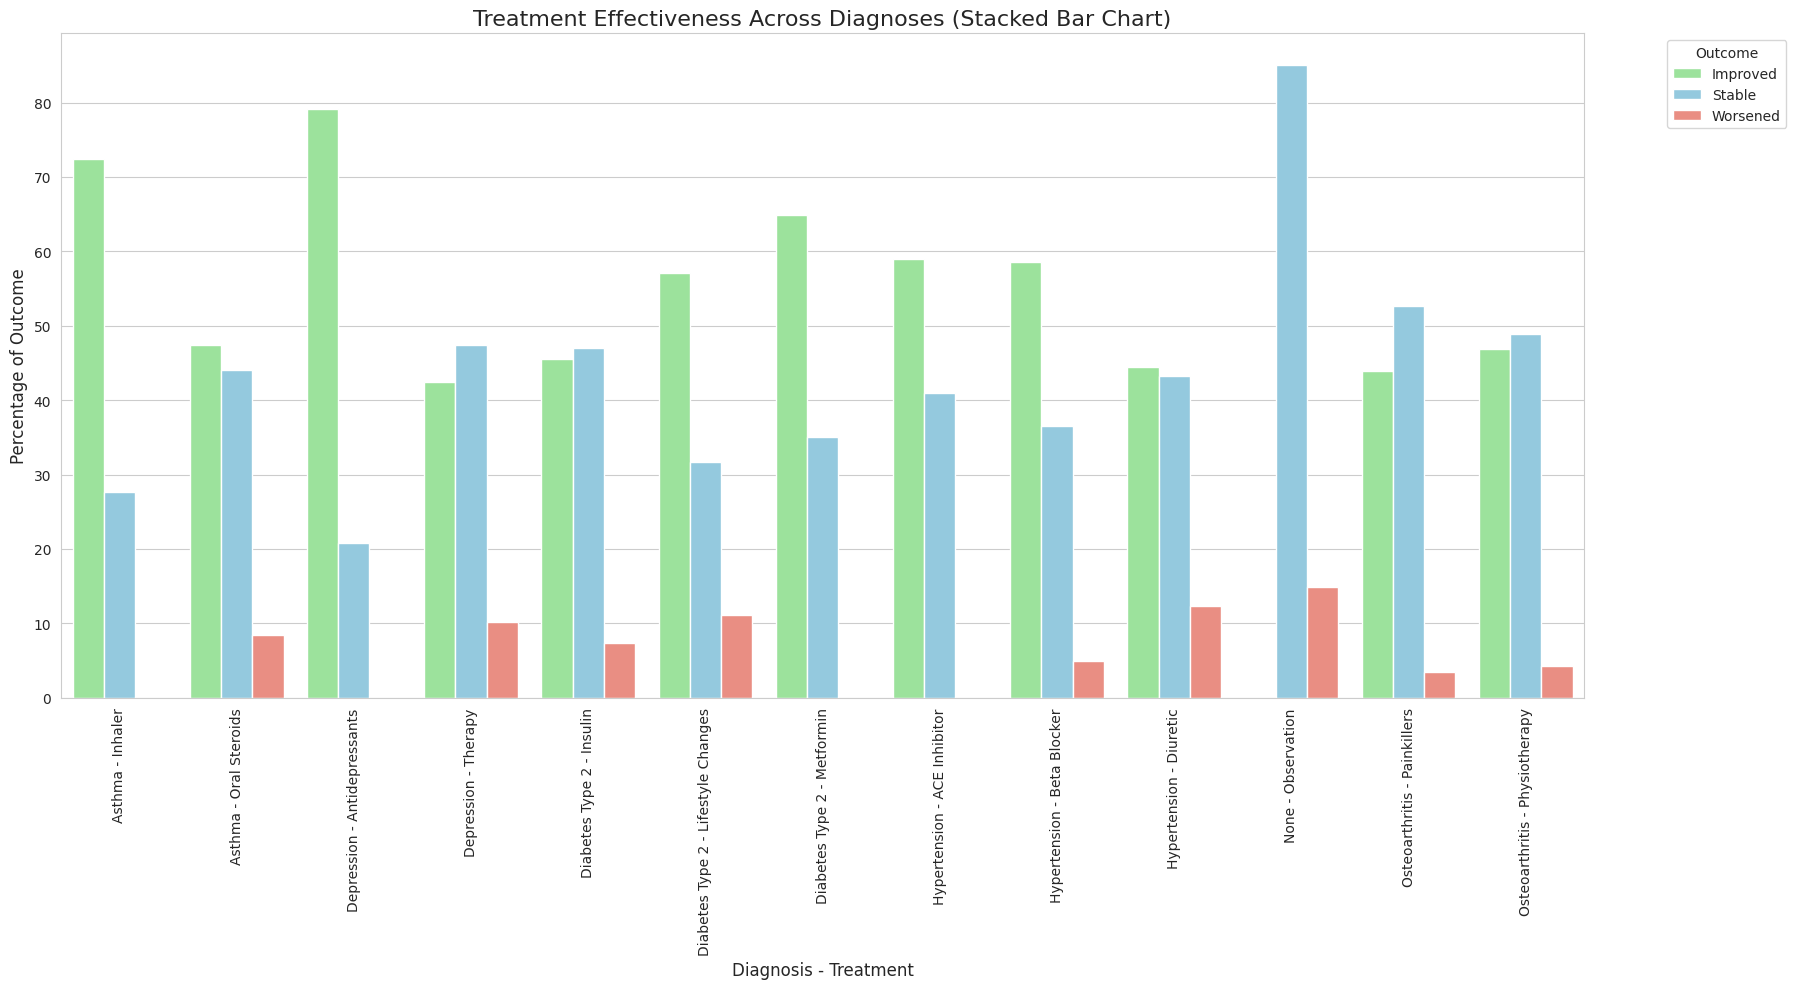

In [19]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")

# Reset index to make 'diagnosis' and 'treatment' regular columns for plotting
plot_data = treatment_effectiveness_percent.reset_index()

# Melt the DataFrame to long format for stacked bar chart
plot_data_melted = plot_data.melt(id_vars=['diagnosis', 'treatment'],
                                 value_vars=['Improved', 'Stable', 'Worsened'],
                                 var_name='outcome_type',
                                 value_name='percentage')

# Create a combined 'Diagnosis - Treatment' column for the x-axis
plot_data_melted['diagnosis_treatment'] = plot_data_melted['diagnosis'] + ' - ' + plot_data_melted['treatment']

plt.figure(figsize=(18, 10)) # Adjust figure size for better readability
sns.barplot(x='diagnosis_treatment', y='percentage', hue='outcome_type', data=plot_data_melted,
            palette={'Improved': 'lightgreen', 'Stable': 'skyblue', 'Worsened': 'salmon'},
            order=plot_data_melted['diagnosis_treatment'].unique()) # Maintain original order

plt.title('Treatment Effectiveness Across Diagnoses (Stacked Bar Chart)', fontsize=16)
plt.xlabel('Diagnosis - Treatment', fontsize=12)
plt.ylabel('Percentage of Outcome', fontsize=12)
plt.xticks(rotation=90, fontsize=10) # Rotate labels to prevent overlap
plt.yticks(fontsize=10)
plt.legend(title='Outcome', bbox_to_anchor=(1.05, 1), loc='upper left') # Place legend outside
plt.tight_layout() # Adjust layout to prevent labels from being cut off
plt.show()

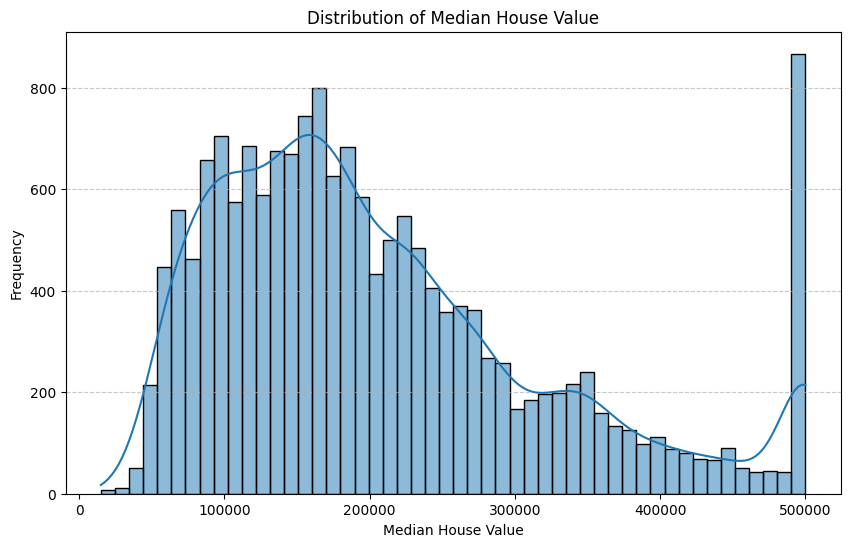

In [5]:
import matplotlib.pyplot as plt
import seaborn as sns

# Check if 'median_house_value' column exists before plotting
if 'median_house_value' in df.columns:
    plt.figure(figsize=(10, 6))
    sns.histplot(df['median_house_value'], bins=50, kde=True)
    plt.title('Distribution of Median House Value')
    plt.xlabel('Median House Value')
    plt.ylabel('Frequency')
    plt.grid(axis='y', linestyle='--', alpha=0.7)
    plt.show()
else:
    print("Error: 'median_house_value' column not found in the DataFrame. Please check the dataset.")

### Building a Decision Tree Model for Outcome Prediction

To predict treatment outcomes, we'll use a Decision Tree Classifier. This involves:
1.  **Feature Selection and Encoding**: Identifying relevant patient characteristics and treatment details as features, and converting categorical data into numerical format.
2.  **Data Splitting**: Dividing the dataset into training and testing sets to evaluate the model's performance on unseen data.
3.  **Model Training**: Training the Decision Tree Classifier on the training data.
4.  **Model Evaluation**: Assessing the model's accuracy and other performance metrics.
5.  **Tree Visualization**: Visualizing the decision-making process of the trained tree.

In [20]:
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import classification_report, accuracy_score
import pandas as pd

# 1. Prepare the data: Define features (X) and target (y)
# Features will include age, gender, diagnosis, treatment, and lab results.
# The target variable is 'outcome'.

features = ['age', 'gender', 'diagnosis', 'treatment', 'bp_systolic', 'bp_diastolic', 'glucose', 'cholesterol']
target = 'outcome'

X = df[features]
y = df[target]

# Convert categorical features into numerical using one-hot encoding
X = pd.get_dummies(X, columns=['gender', 'diagnosis', 'treatment'], drop_first=True)

# 2. Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

print("Data preparation and splitting complete.")
print(f"Training set shape: {X_train.shape}")
print(f"Testing set shape: {X_test.shape}")

Data preparation and splitting complete.
Training set shape: (800, 23)
Testing set shape: (200, 23)


In [21]:
# 3. Train the Decision Tree Classifier model
model = DecisionTreeClassifier(random_state=42)
model.fit(X_train, y_train)

print("Decision Tree Classifier trained successfully.")

Decision Tree Classifier trained successfully.


In [22]:
# 4. Evaluate the model
y_pred = model.predict(X_test)

print("\n--- Model Evaluation ---")
print(f"Accuracy: {accuracy_score(y_test, y_pred):.2f}")
print("\nClassification Report:")
print(classification_report(y_test, y_pred))

print("Model evaluation complete. The accuracy and classification report provide insights into the model's predictive capability.")


--- Model Evaluation ---
Accuracy: 0.60

Classification Report:
              precision    recall  f1-score   support

    Improved       0.68      0.62      0.65        90
      Stable       0.61      0.64      0.62        96
    Worsened       0.17      0.21      0.19        14

    accuracy                           0.60       200
   macro avg       0.49      0.49      0.49       200
weighted avg       0.61      0.60      0.60       200

Model evaluation complete. The accuracy and classification report provide insights into the model's predictive capability.


### Visualizing the Decision Tree

A decision tree can be visually represented to understand its decision-making logic. For a model with many features and depth, the visualization can be quite large. We'll save it as a PNG file for better readability.

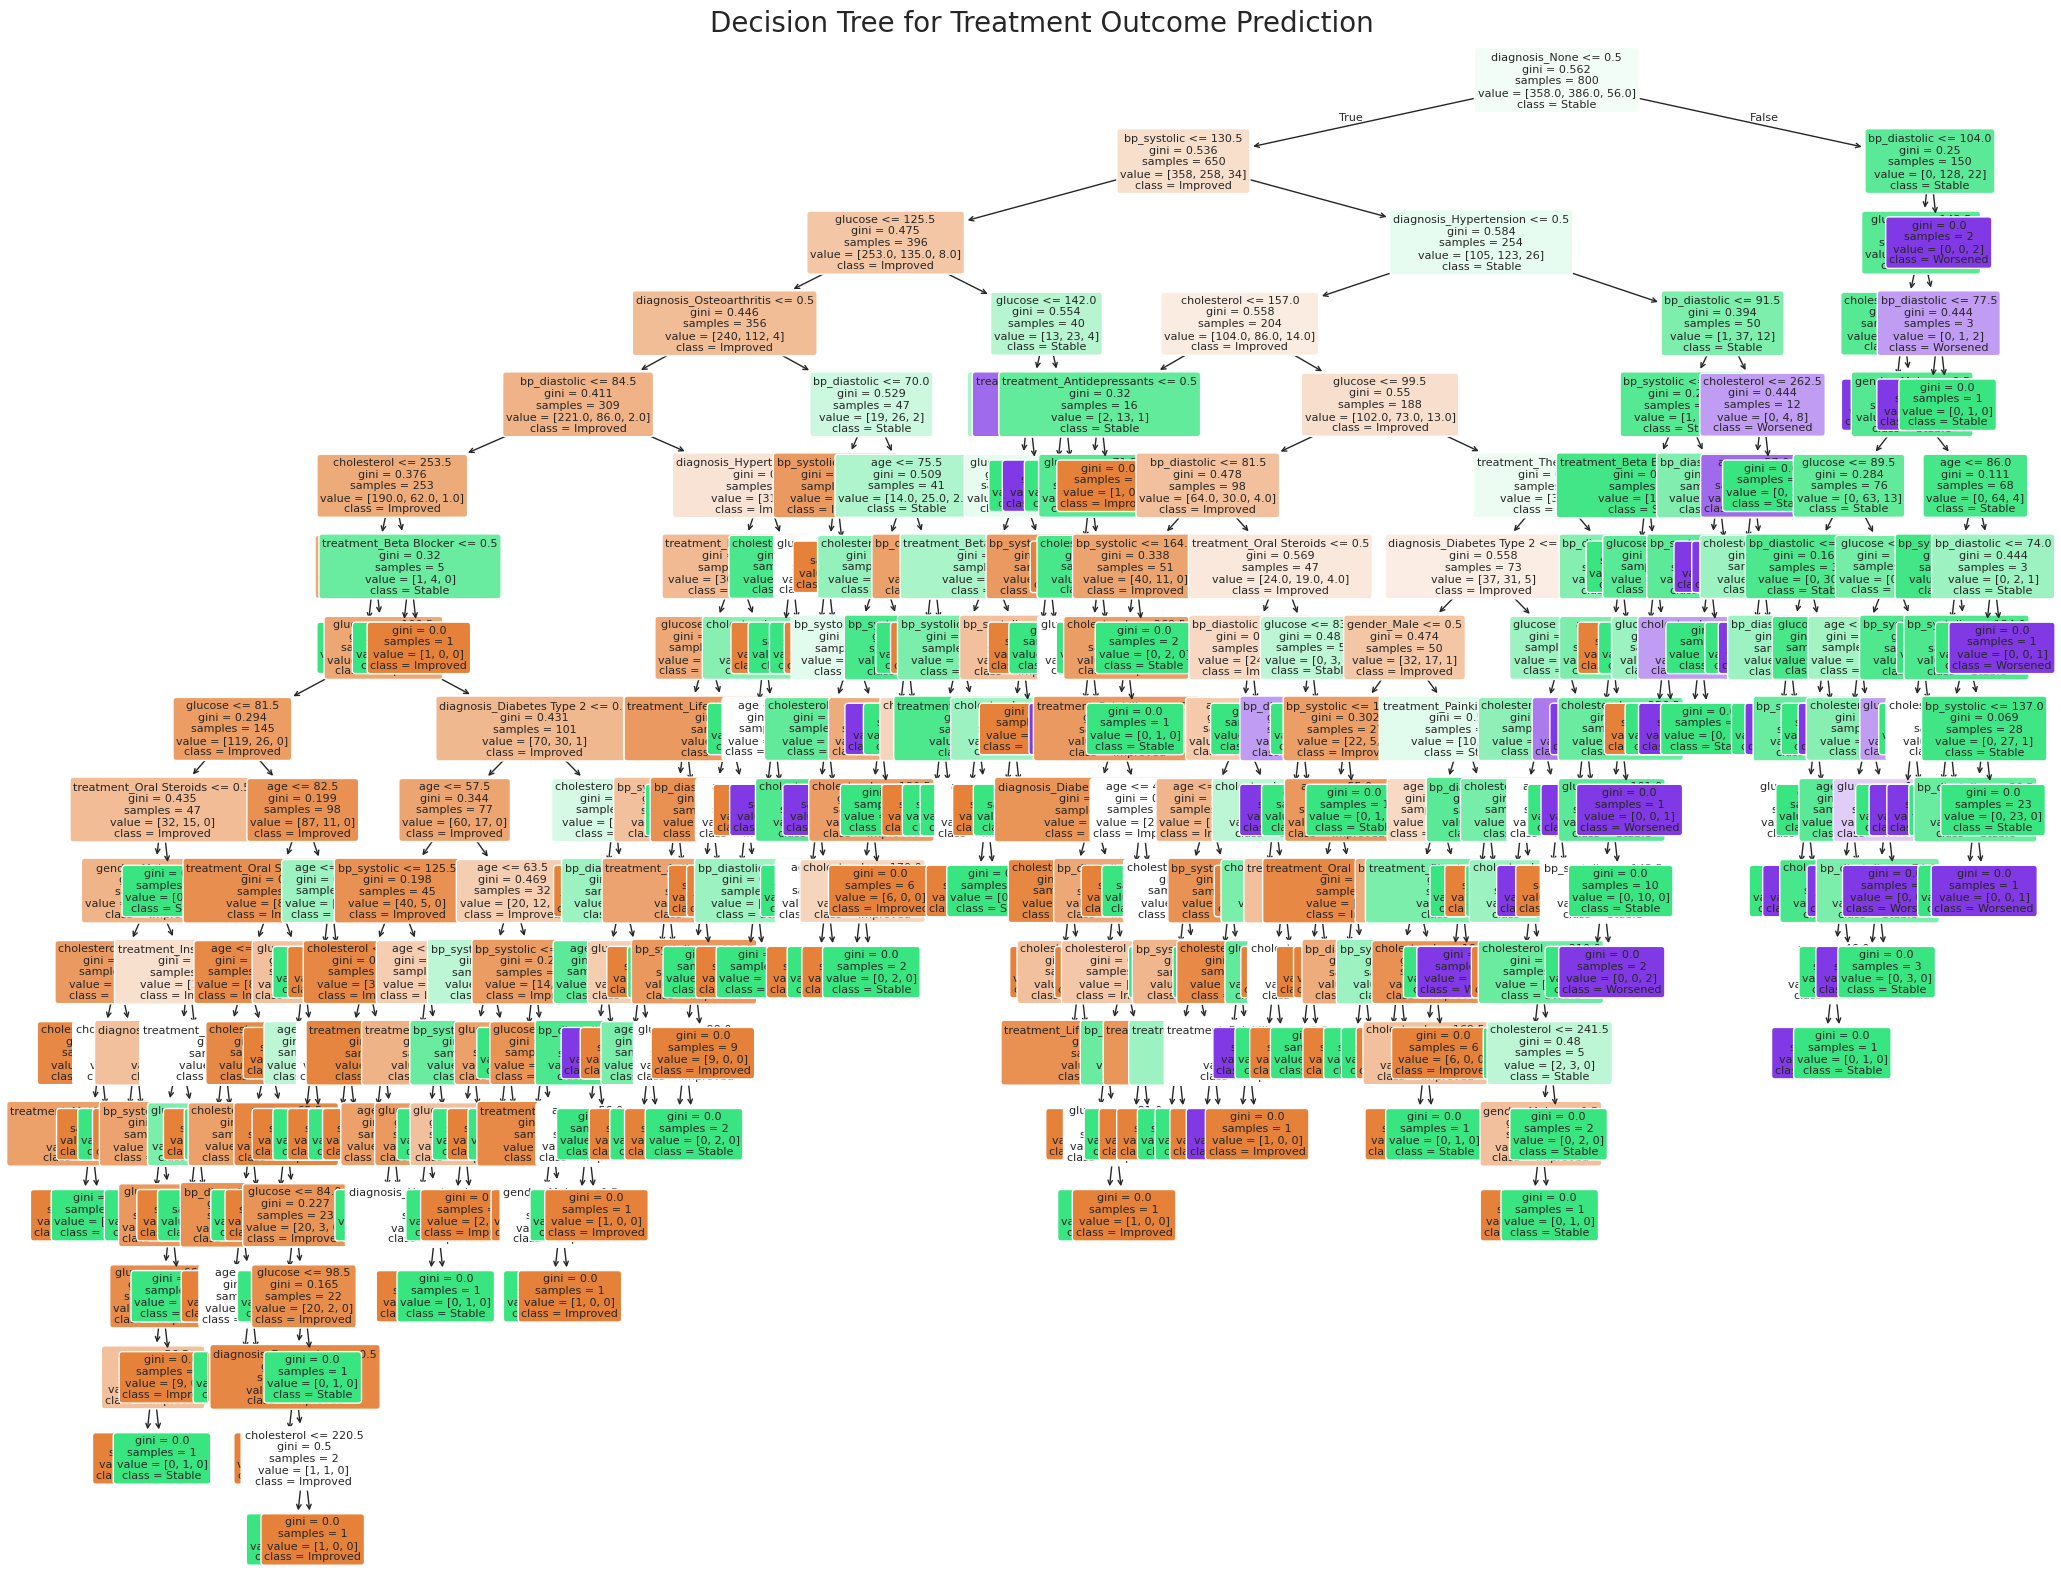

Decision tree visualization saved as 'decision_tree.png'. You can view it in the files sidebar.


In [23]:
from sklearn.tree import plot_tree
import matplotlib.pyplot as plt

plt.figure(figsize=(25, 20)) # Adjust size for better readability
plot_tree(model,
          feature_names=X.columns.tolist(),  # Use actual column names
          class_names=model.classes_.tolist(), # Use actual class names (outcomes)
          filled=True,
          rounded=True,
          proportion=False,
          fontsize=8)
plt.title('Decision Tree for Treatment Outcome Prediction', fontsize=20)
plt.savefig('decision_tree.png', dpi=300) # Save the plot as a high-resolution PNG
plt.show()

print("Decision tree visualization saved as 'decision_tree.png'. You can view it in the files sidebar.")

### Comparing Decision Tree with Random Forest

To see if we can improve the prediction of treatment outcomes, let's compare our Decision Tree model with a Random Forest Classifier. Random Forests are an ensemble learning method that builds multiple decision trees and merges their predictions to get a more accurate and stable prediction.

In [24]:
from sklearn.ensemble import RandomForestClassifier

# 1. Train the Random Forest Classifier model
rf_model = RandomForestClassifier(random_state=42, n_estimators=100) # Using 100 trees
rf_model.fit(X_train, y_train)

print("Random Forest Classifier trained successfully.")

Random Forest Classifier trained successfully.


In [25]:
# 2. Evaluate the Random Forest model
y_pred_rf = rf_model.predict(X_test)

print("\n--- Random Forest Model Evaluation ---")
print(f"Accuracy: {accuracy_score(y_test, y_pred_rf):.2f}")
print("\nClassification Report:")
print(classification_report(y_test, y_pred_rf))

print("Random Forest model evaluation complete.")


--- Random Forest Model Evaluation ---
Accuracy: 0.69

Classification Report:
              precision    recall  f1-score   support

    Improved       0.69      0.80      0.74        90
      Stable       0.70      0.69      0.69        96
    Worsened       0.50      0.07      0.12        14

    accuracy                           0.69       200
   macro avg       0.63      0.52      0.52       200
weighted avg       0.68      0.69      0.68       200

Random Forest model evaluation complete.


### Comparison of Decision Tree and Random Forest

Let's put the performance metrics of both models side-by-side for an easier comparison.

In [26]:
print("\n--- Model Comparison ---")

dt_accuracy = accuracy_score(y_test, model.predict(X_test))
rf_accuracy = accuracy_score(y_test, rf_model.predict(X_test))

print(f"Decision Tree Accuracy: {dt_accuracy:.2f}")
print(f"Random Forest Accuracy: {rf_accuracy:.2f}")

print("\nDecision Tree Classification Report:")
print(classification_report(y_test, model.predict(X_test)))

print("\nRandom Forest Classification Report:")
print(classification_report(y_test, rf_model.predict(X_test)))


--- Model Comparison ---
Decision Tree Accuracy: 0.60
Random Forest Accuracy: 0.69

Decision Tree Classification Report:
              precision    recall  f1-score   support

    Improved       0.68      0.62      0.65        90
      Stable       0.61      0.64      0.62        96
    Worsened       0.17      0.21      0.19        14

    accuracy                           0.60       200
   macro avg       0.49      0.49      0.49       200
weighted avg       0.61      0.60      0.60       200


Random Forest Classification Report:
              precision    recall  f1-score   support

    Improved       0.69      0.80      0.74        90
      Stable       0.70      0.69      0.69        96
    Worsened       0.50      0.07      0.12        14

    accuracy                           0.69       200
   macro avg       0.63      0.52      0.52       200
weighted avg       0.68      0.69      0.68       200

